In [7]:
# RESTART CELL - Run this first to clear PSS/E state
# If you get errors, restart the kernel first, then run all cells from here

import os, sys

# PSS/E path setup  
PSSE_PATH = r"C:\Program Files\PTI\PSSE35\35.5"
sys.path.insert(0, rf"{PSSE_PATH}\PSSPY37")
sys.path.insert(0, rf"{PSSE_PATH}\PSSBIN")
os.environ["PATH"] = rf"{PSSE_PATH}\PSSPY37;{PSSE_PATH}\PSSBIN;" + os.environ["PATH"]

import psspy
import dyntools

print(f"dyntools loaded from: {dyntools.__file__}")
print(f"psspy loaded from: {psspy.__file__}")

dyntools loaded from: C:\Program Files\PTI\PSSE35\35.5\PSSPY37\dyntools.pyc
psspy loaded from: C:\Program Files\PTI\PSSE35\35.5\PSSPY37\psspy.pyc


# Prototype 2: Add New Bus + Load Proxy for WEC Dynamic Simulation

This notebook extends `prototype.ipynb` by:
1. **Adding a NEW bus** to the grid (not just using an existing bus)
2. **Adding a transmission line** connecting the new bus to the grid
3. **Adding a load proxy** on the new bus for WEC power injection

This approach is more realistic for offshore WEC farms that connect via a dedicated POI (Point of Interconnection).

## Why Load Proxy?

The **load proxy approach** uses `load_data_6()` + `load_chng_5()` with negative P/Q values to represent generation. This is the same pattern used in the NREL cpds_cosim and is ideal for FMU co-simulation because:

- ✅ **Works with any DYR file** - loads are algebraic, no dynamic model needed
- ✅ **Direct P/Q control** - perfect match for IBR/FMU outputs
- ✅ **No DYR modifications** - add any number of WEC buses dynamically

In [8]:
# Part 1 - Initialize PSS/E and load case
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize PSS/E
psspy.psseinit(50)

# File paths
case_dir = Path.cwd()
if not (case_dir / 'nrel_test').exists():
    case_dir = case_dir
else:
    case_dir = case_dir / 'nrel_test'

ieee14_dir = (case_dir / '..' / 'cpds_cosim' / 'machine_1' / 'Transmission' / 'ieee_14').resolve()
RAW_FILE = ieee14_dir / 'ieee14.raw'
DYR_FILE = ieee14_dir / 'ieee14.dyr'
OUT_FILE = case_dir / 'prototype2_dynamic.out'

print(f"RAW: {RAW_FILE}")
print(f"DYR: {DYR_FILE}")
print(f"OUT: {OUT_FILE}")

# Load RAW file using case() as required for dynamics
ierr = psspy.case(str(RAW_FILE))
print(f"case(): ierr={ierr}")

# If case() fails, try read() and check if power flow needed
if ierr != 0:
    print("case() failed, trying read()...")
    ierr = psspy.read(0, str(RAW_FILE))
    print(f"read(): ierr={ierr}")

# Show buses
ierr, bus_numbers = psspy.abusint(-1, 2, 'NUMBER')
ierr, bus_names = psspy.abuschar(-1, 2, 'NAME')
if bus_numbers and bus_numbers[0]:
    print(f"\nBuses: {len(bus_numbers[0])}")
    for num, name in zip(bus_numbers[0], bus_names[0]):
        print(f"  {num}: {name.strip()}")

RAW: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.raw
DYR: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.dyr
OUT: c:\Users\alexb\research\WEC-GRID\nrel_test\prototype2_dynamic.out
case(): ierr=4
case() failed, trying read()...
read(): ierr=11

Buses: 15
  1: BUS1
  2: BUS2
  3: BUS3
  4: BUS4
  5: BUS5
  6: BUS6
  7: BUS7
  8: BUS8
  9: BUS9
  10: BUS10
  11: BUS11
  12: BUS12
  13: BUS13
  14: BUS14
  100: WEC_100


In [9]:
# Part 2 - Add WEC topology BEFORE dynamic conversion
# All topology changes must happen here before conl/cong/ordr/fact/tysl

WEC_BUS = 100
CONNECTING_BUS = 11
WEC_LOAD_ID = 'W1'

# Get base voltage
ierr, base_kv = psspy.busdat(CONNECTING_BUS, 'BASE')
print(f"Bus {CONNECTING_BUS} base: {base_kv:.1f} kV")

# Add WEC bus
ierr = psspy.bus_data_4(
    ibus=WEC_BUS,
    inode=0,
    intgar1=1,  # PQ bus
    realar1=base_kv,
    name=f"WEC_{WEC_BUS}",
)
print(f"bus_data_4: ierr={ierr}")

# Add branch
realar = [0.0] * 12
realar[0] = 0.01  # R
realar[1] = 0.05  # X
realar[2] = 0.02  # B
ierr = psspy.branch_data_3(WEC_BUS, CONNECTING_BUS, '1', 1, realar)
print(f"branch_data_3: ierr={ierr}")

# Add load proxy at zero
intgar = [1, 1, 1, 1, 1, 0, 0]
realar_load = [0.0] * 8
ierr = psspy.load_data_6(WEC_BUS, WEC_LOAD_ID, intgar, realar_load)
print(f"load_data_6: ierr={ierr}")

# Solve power flow
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
print(f"fnsl: ierr={ierr}")

ierr, v_pu = psspy.busdat(WEC_BUS, 'PU')
print(f"\nWEC bus {WEC_BUS}: {v_pu:.4f} pu")
print("Topology complete - ready for dynamic conversion")

Bus 11 base: 138.0 kV
bus_data_4: ierr=10
branch_data_3: ierr=10
load_data_6: ierr=6
fnsl: ierr=5

WEC bus 100: 1.0001 pu
Topology complete - ready for dynamic conversion


In [10]:
# Part 3 - Dynamic conversion (topology must be final)
# Order: conl (3 steps!) -> cong -> ordr -> fact -> tysl -> dyre_new

print("Step 1: Convert loads (CONL is a 3-step process)...")

# CONL Step 1: Initialize for load conversion (apiopt=1)
ierr, remaining = psspy.conl(-1, 1, 1, [0, 0], [0.0, 0.0, 0.0, 0.0])
print(f"  conl(apiopt=1): ierr={ierr}, remaining={remaining}")

# CONL Step 2: Convert loads (apiopt=2)
# status=[0,0]: convert existing MVA load, all buses
# loadin=[100,0,100,0]: 100% P to const current, 0% to const admittance
#                       100% Q to const current, 0% to const admittance
ierr, remaining = psspy.conl(-1, 1, 2, [0, 0], [100.0, 0.0, 100.0, 0.0])
print(f"  conl(apiopt=2): ierr={ierr}, remaining={remaining}")

# CONL Step 3: Postprocessing cleanup (apiopt=3)
ierr, remaining = psspy.conl(-1, 1, 3, [0, 0], [0.0, 0.0, 0.0, 0.0])
print(f"  conl(apiopt=3): ierr={ierr}, remaining={remaining}")

print("Step 2: Convert generators...")
ierr = psspy.cong(0)
print(f"  cong: {ierr}")

print("Step 3: Order network...")
ierr = psspy.ordr(0)
print(f"  ordr: {ierr}")

print("Step 4: Factorize...")
ierr = psspy.fact()
print(f"  fact: {ierr}")

print("Step 5: Initialize...")
ierr = psspy.tysl(0)
print(f"  tysl: {ierr}")

print("Step 6: Load DYR...")
ierr = psspy.dyre_new([1,1,1,1], str(DYR_FILE), '', '', '')
print(f"  dyre_new: {ierr}")

if ierr != 0:
    print(f"\nWARNING: dyre_new failed with ierr={ierr}")
else:
    print("\nDynamic initialization complete")

Step 1: Convert loads (CONL is a 3-step process)...
  conl(apiopt=1): ierr=5, remaining=None
  conl(apiopt=2): ierr=0, remaining=0
  conl(apiopt=3): ierr=0, remaining=0
Step 2: Convert generators...
  cong: 0
Step 3: Order network...
  ordr: 0
Step 4: Factorize...
  fact: 0
Step 5: Initialize...
  tysl: 0
Step 6: Load DYR...
  dyre_new: 0

Dynamic initialization complete


In [11]:
# Part 4 - Load WEC data

database_path = (case_dir / '..' / 'examples' / 'WECGrid.db').resolve()
print(f"Database: {database_path}")

wec_sim_id = 1
NUM_WEC_DEVICES = 100  # Larger farm for visible impact

conn = sqlite3.connect(database_path)
query = '''
    SELECT time_sec, device_index, p_w, q_var
    FROM wec_power_results
    WHERE wec_sim_id = ?
    ORDER BY time_sec, device_index
'''
wec_power_df = pd.read_sql_query(query, conn, params=(wec_sim_id,))
conn.close()

# Aggregate and scale
farm_power = wec_power_df.groupby('time_sec').agg({'p_w': 'sum', 'q_var': 'sum'}).reset_index()
farm_power['p_mw'] = farm_power['p_w'] / 1e6 * NUM_WEC_DEVICES
farm_power['q_mvar'] = farm_power['q_var'] / 1e6 * NUM_WEC_DEVICES

# Select time window
sim_step = 0.1
wec_start, wec_end = 100.0, 130.0  # Shorter for faster runs

profile = farm_power.query('time_sec >= @wec_start and time_sec <= @wec_end').copy()
profile = profile.reset_index(drop=True)
profile['sim_time'] = np.arange(len(profile)) * sim_step

print(f"\nWEC Farm ({NUM_WEC_DEVICES} devices):")
print(f"  Power range: {profile['p_mw'].min():.2f} to {profile['p_mw'].max():.2f} MW")
print(f"  Time steps: {len(profile)}")

Database: C:\Users\alexb\research\WEC-GRID\examples\WECGrid.db

WEC Farm (100 devices):
  Power range: 1.31 to 1.42 MW
  Time steps: 301

WEC Farm (100 devices):
  Power range: 1.31 to 1.42 MW
  Time steps: 301


In [12]:
# Part 5 - Run dynamic simulation

# Clean up old files
for ext in (".out", ".outx"):
    f = OUT_FILE.with_suffix(ext)
    if f.exists():
        f.unlink()
        print(f"Deleted {f.name}")

psspy.progress_output(6, '', [0, 0])

# Configure channels BEFORE strt_2
psspy.chsb(0, 1, [-1, -1, -1, 1, 13, 0])  # voltages
psspy.chsb(0, 1, [-1, -1, -1, 1, 12, 0])  # frequencies
print("Channels configured")

# Start simulation
ierr = psspy.strt_2([0, 0], str(OUT_FILE))
print(f"strt_2: ierr={ierr}")
if ierr != 0:
    raise RuntimeError(f"strt_2 failed: ierr={ierr}")

# Initial step
psspy.run(0, 0.0, 1, 1, 0)
print("Simulation started...")

results = []
current_time = 0.0

print("\nRunning with WEC injection...")
for idx, row in enumerate(profile.iterrows()):
    _, row = row
    target_time = current_time + sim_step
    p_mw = float(row['p_mw'])
    q_mvar = float(row['q_mvar'])
    
    # Inject via negative load
    psspy.load_chng_5(WEC_BUS, WEC_LOAD_ID, [], [-p_mw, -q_mvar, 0.0, 0.0, 0.0, 0.0])
    psspy.run(0, target_time, 1, 1, 0)
    
    ierr, v_wec = psspy.busdat(WEC_BUS, 'PU')
    ierr, v_conn = psspy.busdat(CONNECTING_BUS, 'PU')
    
    results.append({
        'sim_time': target_time,
        'p_mw': p_mw,
        'q_mvar': q_mvar,
        'v_wec_bus': v_wec,
        'v_connecting_bus': v_conn,
    })
    current_time = target_time
    
    if idx % 50 == 0:
        print(f"  Step {idx}: t={target_time:.1f}s, P={p_mw:.2f}MW, V={v_wec:.4f}pu")

psspy.progress_output(1, '', [0, 0])
print("\nSimulation complete.")

# Read output file
print(f"\nReading {OUT_FILE}...")
chn = dyntools.CHNF(str(OUT_FILE))
short_title, chanid, chandata = chn.get_data()

print(f"Channels: {len(chanid)}")
for k, v in list(chanid.items())[:10]:
    print(f"  {k}: {v}")

time_out = np.array(chandata['time'])
print(f"\nTime: {time_out[0]:.2f} to {time_out[-1]:.2f}s ({len(time_out)} pts)")

# Find frequency channel
freq_channel = None
for k, v in chanid.items():
    if 'FREQ' in str(v).upper():
        freq_channel = k
        print(f"Frequency channel: {k}")
        break

results_df = pd.DataFrame(results)

if freq_channel and freq_channel in chandata:
    freq_data = np.array(chandata[freq_channel])
    freq_interp = np.interp(results_df['sim_time'], time_out, freq_data)
    if np.abs(freq_interp).max() < 1.0:
        results_df['freq_hz'] = 60.0 * (1.0 + freq_interp)
    else:
        results_df['freq_hz'] = freq_interp
else:
    results_df['freq_hz'] = 60.0

print(f"\nResults:")
print(f"  V_wec: {results_df['v_wec_bus'].min():.4f} - {results_df['v_wec_bus'].max():.4f} pu")
print(f"  V_conn: {results_df['v_connecting_bus'].min():.4f} - {results_df['v_connecting_bus'].max():.4f} pu")
print(f"  Freq: {results_df['freq_hz'].min():.4f} - {results_df['freq_hz'].max():.4f} Hz")

Channels configured
strt_2: ierr=0
Simulation started...

Running with WEC injection...
  Step 0: t=0.1s, P=1.32MW, V=1.0015pu
  Step 50: t=5.1s, P=1.32MW, V=1.0010pu
  Step 50: t=5.1s, P=1.32MW, V=1.0010pu
  Step 100: t=10.1s, P=1.35MW, V=1.0011pu
  Step 100: t=10.1s, P=1.35MW, V=1.0011pu
  Step 150: t=15.1s, P=1.40MW, V=1.0012pu
  Step 150: t=15.1s, P=1.40MW, V=1.0012pu
  Step 200: t=20.1s, P=1.41MW, V=1.0011pu
  Step 200: t=20.1s, P=1.41MW, V=1.0011pu
  Step 250: t=25.1s, P=1.39MW, V=1.0011pu
  Step 250: t=25.1s, P=1.39MW, V=1.0011pu
  Step 300: t=30.1s, P=1.39MW, V=1.0011pu

Simulation complete.

Reading c:\Users\alexb\research\WEC-GRID\nrel_test\prototype2_dynamic.out...
Channels: 31
  time: Time(s)
  1: VOLT 1 [BUS1 69.000]
  2: VOLT 2 [BUS2 69.000]
  3: VOLT 3 [BUS3 69.000]
  4: VOLT 4 [BUS4 69.000]
  5: VOLT 5 [BUS5 69.000]
  6: VOLT 6 [BUS6 138.00]
  7: VOLT 7 [BUS7 138.00]
  8: VOLT 8 [BUS8 69.000]
  9: VOLT 9 [BUS9 138.00]

Time: -0.02 to 30.11s (3917 pts)
Frequency channel:

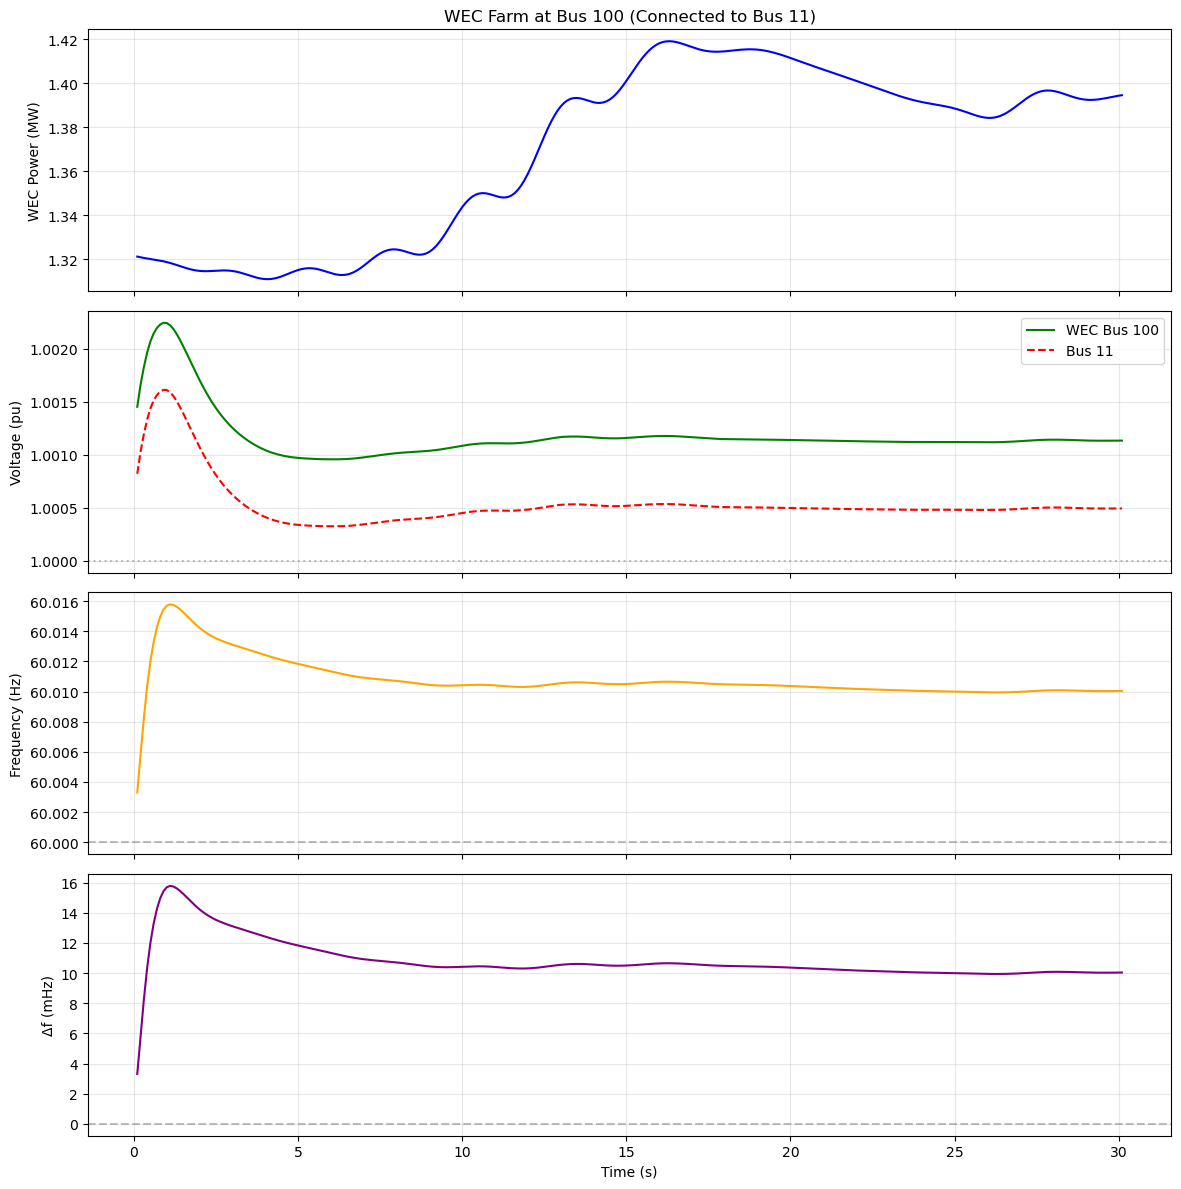


--- Summary ---
WEC bus 100 connected to bus 11
WEC power: 1.37 MW (mean)
Voltage difference: 0.64 mpu (mean)
Frequency deviation: 10.83 mHz (mean)


In [13]:
# Part 6 - Visualize results

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# WEC Power
ax1 = axes[0]
ax1.plot(results_df['sim_time'], results_df['p_mw'], 'b-', lw=1.5)
ax1.set_ylabel('WEC Power (MW)')
ax1.set_title(f'WEC Farm at Bus {WEC_BUS} (Connected to Bus {CONNECTING_BUS})')
ax1.grid(alpha=0.3)

# Voltage at both buses
ax2 = axes[1]
ax2.plot(results_df['sim_time'], results_df['v_wec_bus'], 'g-', lw=1.5, label=f'WEC Bus {WEC_BUS}')
ax2.plot(results_df['sim_time'], results_df['v_connecting_bus'], 'r--', lw=1.5, label=f'Bus {CONNECTING_BUS}')
ax2.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax2.set_ylabel('Voltage (pu)')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

# Frequency
ax3 = axes[2]
ax3.plot(results_df['sim_time'], results_df['freq_hz'], 'orange', lw=1.5)
ax3.axhline(60.0, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylabel('Frequency (Hz)')
ax3.grid(alpha=0.3)

# Frequency deviation
ax4 = axes[3]
freq_dev_mhz = (results_df['freq_hz'] - 60.0) * 1000
ax4.plot(results_df['sim_time'], freq_dev_mhz, 'purple', lw=1.5)
ax4.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax4.set_ylabel('Δf (mHz)')
ax4.set_xlabel('Time (s)')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Summary ---")
print(f"WEC bus {WEC_BUS} connected to bus {CONNECTING_BUS}")
print(f"WEC power: {results_df['p_mw'].mean():.2f} MW (mean)")
v_diff = (results_df['v_wec_bus'] - results_df['v_connecting_bus']) * 1000
print(f"Voltage difference: {v_diff.mean():.2f} mpu (mean)")
print(f"Frequency deviation: {freq_dev_mhz.mean():.2f} mHz (mean)")

---

## Summary: New Bus + Load Proxy Approach

### What we demonstrated:

1. **Added a NEW bus** (Bus 100) to the IEEE 14-bus system
2. **Connected it via transmission line** to Bus 11
3. **Added a load proxy** for WEC power injection
4. **Ran dynamic simulation** without modifying the DYR file

### Why this works with DYR:

- **Loads don't need dynamic models** - they're algebraic in PSS/E
- The DYR file only contains models for generators, exciters, governors, etc.
- Adding a new PQ bus with a load is fully compatible

### Comparison with Generator Approach:

| Aspect | Generator (`machine_data_4`) | Load Proxy (`load_data_6`) |
|--------|------------------------------|----------------------------|
| DYR required | Yes - needs GENCLS/GENROU | **No** |
| Voltage control | Yes (PV bus) | No (PQ bus) |
| Reactive support | Via AVR model | Via Q injection |
| FMU integration | Complex | **Simple** |

### For FMU Co-simulation:

The load proxy approach is ideal because:
- No need to create dynamic model entries in DYR
- Direct P/Q control via `load_chng_5()`
- Can add any number of WEC buses without DYR changes